# Exploratory Data Analysis (EDA) Adult Income Dataset

This project performs data cleaning and exploratory data analysis (EDA) on the Adult Income dataset to understand patterns affecting income levels.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the dataset

df = pd.read_csv("../data/raw_data.csv")

## Data cleaning

### Standardise column names and strings values

In [4]:
# clean column names
df.columns = df.columns.str.lower().str.strip().str.replace("-", "_", regex=False)

# clean text values
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.lower().str.strip().str.replace("-", "_", regex=False)


### Handling missing values

In [5]:
# replace "?" with NaN
df = df.replace("?", pd.NA)

- Missing values originally represented as "?" were converted to NaN

In [6]:
# fill missing categorical values
df["workclass"] = df["workclass"].fillna("unknown")
df["occupation"] = df["occupation"].fillna("unknown")
df["native_country"] = df["native_country"].fillna("unknown")

- Missing values originally represented as "?" were converted to NaN  
- Missing values detected in workclass, occupation, native_country  
- Filled with "unknown" to preserve data instead of dropping rows  
- No inconsistencies found in categorical values (case sensitivity or spacing)

### Fixing target variable (Income)

In [7]:
# clean and convert income
# ensure column is string (prevents .str errors on rerun)
df["income"] = df["income"].astype(str)
df["income"] = df["income"].str.strip().str.replace(".", "", regex=False)
df["income"] = df["income"].map({"<=50k": 0, ">50k": 1})
df["income"] = df["income"].astype("Int64") ## convert to Int64

- Income converted to binary format (0 = <=50K, 1 = >50K)

### Data Type Conversion

In [8]:
# convert categorical columns 
cat_col = df.select_dtypes(include=["object", "string"]).columns
df[cat_col] = df[cat_col].astype("category")

- Converted object columns to category dtype for memory efficiency

### Dropping irrelevant column

In [9]:
df = df.drop(columns=["fnlwgt"])

- fnlwgt represents census sampling weight, not an actual personal attribute Dropped as it does not contribute meaningful signal for prediction

### Remove Duplicates


In [10]:
df = df.drop_duplicates()

## Outlier analysis

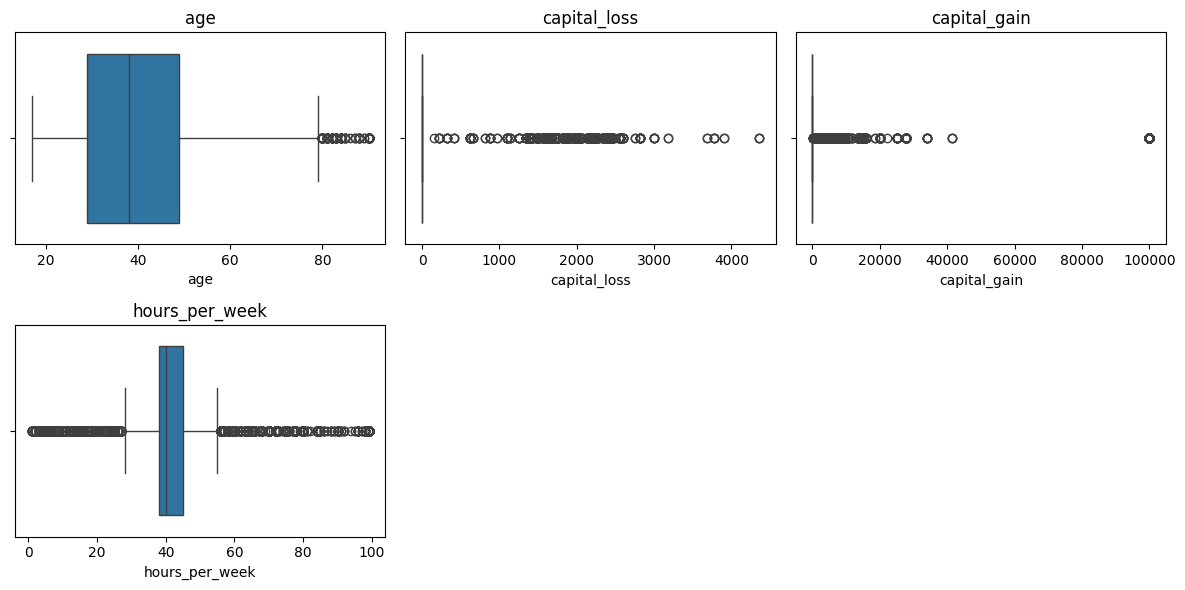

In [11]:
# Visualizing using boxplot to detect outlier
num_cols = ["age", "capital_loss", "capital_gain", "hours_per_week"]

plt.figure(figsize=(12, 6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    sns.boxplot(x=df[col]) 
    plt.title(col)

plt.tight_layout()
plt.show()



### Key Insights

- Majority of individuals (~70–75%) fall between ages 25–50, with a small number of high-end outliers above 80
- Capital_gain and capital_loss are highly right-skewed, with ~90% of values equal to 0, indicating sparse features 
- Hours_per_week is centered around 40 hours, with slight right skew and a few outliers on both lower (<20) and higher (>60) ends

Outliers were not removed, as they represent valid real-world values despite the non-normal distribution and presence of heavy outliers.




### Education_num Distribution (ORDINAL DATA)

Text(0, 0.5, 'Count')

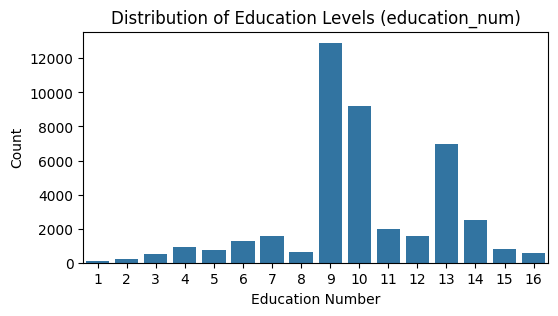

In [12]:
# Countplot Education_num(Ordinal_data)

plt.figure(figsize=(6,3))
sns.countplot(x='education_num', data=df, order=sorted(df['education_num'].unique()))

plt.title("Distribution of Education Levels (education_num)")
plt.xlabel("Education Number")
plt.ylabel("Count")


- Education_num is concentrated between 9–13, indicating most individuals have mid-level education (high school to some college)

### Income Distribution

Text(0, 0.5, 'Count')

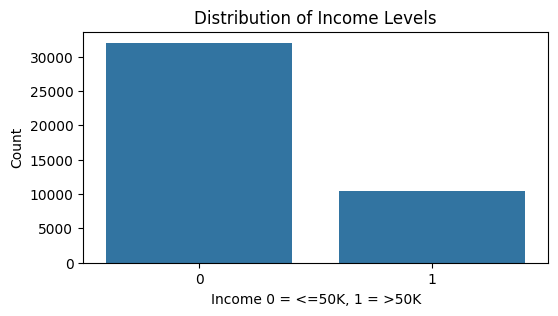

In [13]:
# Income countplot

plt.figure(figsize=(6,3))
sns.countplot(x='income', data=df)

plt.title("Distribution of Income Levels")
plt.xlabel("Income 0 = <=50K, 1 = >50K")
plt.ylabel("Count")

- Dataset is imbalanced, with ~76% in <=50K and ~24% in >50K

In [14]:
# save cleaned dataset
df.to_csv("../data/cleaned_data.csv", index=False)